<a href="https://colab.research.google.com/github/testimonyadewale/msc-grocery-forecasting/blob/main/EDA%20and%20Feature%20engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importation of all libraries

!pip install xgboost --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')
print('All libraries loaded')


All libraries loaded


In [ ]:
#Loading datasets

df = pd.read_csv('/content/drive/MyDrive/MSc_Data/train.csv')
df['date'] = pd.to_datetime(df['date'])

print('Shape:', df.shape)
print('Missing values:\n', df.isnull().sum())
print('\nFirst 5 rows:')
df.head()


Shape: (913000, 4)
Missing values:
 date     0
store    0
item     0
sales    0
dtype: int64

First 5 rows:


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [ ]:
#Plotting sales over time

daily = df.groupby('date')['sales'].sum().reset_index()
fig = px.line(daily, x='date', y='sales',
              title='Total Daily Sales 2013–2017')
fig.show()


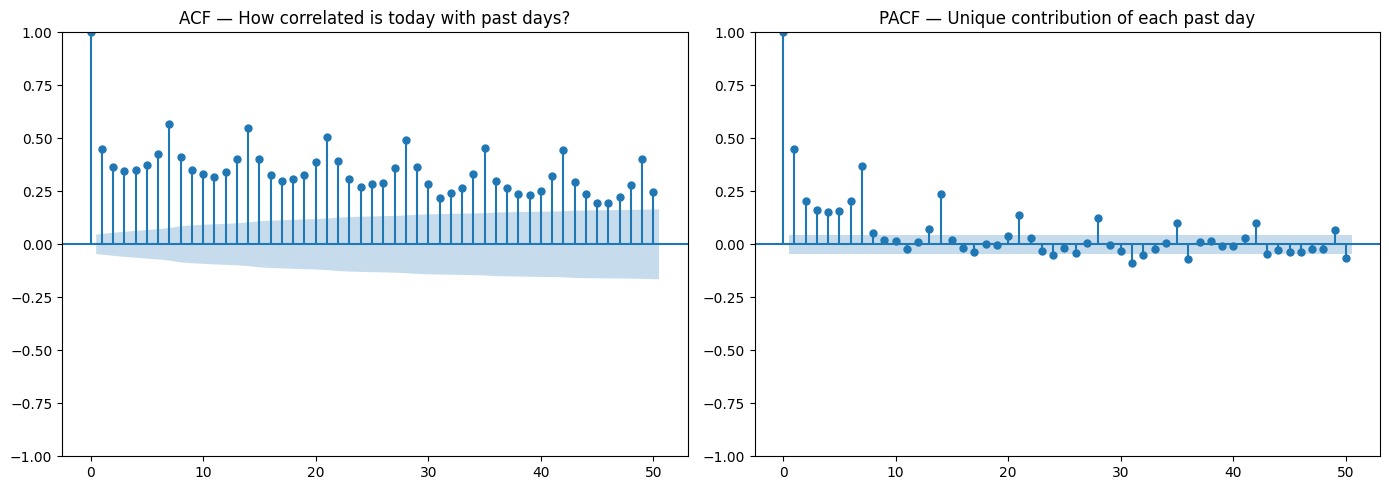

In [ ]:
#ACF and PACF analysis

one = df[(df['store']==1) & (df['item']==1)].sort_values('date')

fig, axes = plt.subplots(1, 2, figsize=(14,5))
plot_acf(one['sales'], lags=50, ax=axes[0])
axes[0].set_title('ACF — How correlated is today with past days?')
plot_pacf(one['sales'], lags=50, ax=axes[1])
axes[1].set_title('PACF — Unique contribution of each past day')
plt.tight_layout()
plt.show()


In [ ]:
#Feature Engineering

df = df.sort_values(['store','item','date']).reset_index(drop=True)

# Lag features
for lag in [1, 7, 14, 28, 365]:
    df[f'lag_{lag}'] = df.groupby(['store','item'])['sales'].shift(lag)

# Rolling statistics (shift first to prevent data leakage)
for w in [7, 28, 84]:
    df[f'rolling_mean_{w}'] = df.groupby(['store','item'])['sales'].transform(
        lambda x: x.shift(1).rolling(w).mean())
for w in [7, 28]:
    df[f'rolling_std_{w}'] = df.groupby(['store','item'])['sales'].transform(
        lambda x: x.shift(1).rolling(w).std())

# Calendar features
df['day_of_week']  = df['date'].dt.dayofweek
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
df['month']        = df['date'].dt.month
df['year']         = df['date'].dt.year
df['quarter']      = df['date'].dt.quarter
df['is_weekend']   = (df['day_of_week'] >= 5).astype(int)

df = df.dropna()
print(f'Dataset ready: {df.shape}')
print(f'Columns: {list(df.columns)}')


Dataset ready: (730500, 20)
Columns: ['date', 'store', 'item', 'sales', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'lag_365', 'rolling_mean_7', 'rolling_mean_28', 'rolling_mean_84', 'rolling_std_7', 'rolling_std_28', 'day_of_week', 'week_of_year', 'month', 'year', 'quarter', 'is_weekend']


In [ ]:
#Train/Test Split

features = ['store','item','lag_1','lag_7','lag_14','lag_28','lag_365',
            'rolling_mean_7','rolling_mean_28','rolling_mean_84',
            'rolling_std_7','rolling_std_28',
            'day_of_week','week_of_year','month','year','quarter','is_weekend']

X = df[features]
y = df['sales']

# Time-based split: 2013-2016 = train, 2017 = test
train_mask = df['date'] < '2017-01-01'
test_mask  = df['date'] >= '2017-01-01'

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f'Training rows: {len(X_train)}')
print(f'Test rows:     {len(X_test)}')


Training rows: 548000
Test rows:     182500
